# 05 - Full pipeline, one sessionRuns the entire study end to end in a single Colab/Kaggle session: data prep -> train all three conditions (base, sft_only, distilled) -> evaluate -> layer analysis. Notebooks 00-04 do the same steps split across separate notebooks, which on both Colab and Kaggle means separate, isolated working directories per notebook - a checkpoint or dataset produced in one notebook's session simply does not exist in another's. This notebook exists to avoid that entirely: run every cell below, top to bottom, in one sitting, and everything stays in the same working directory the whole way through.**Before running:** enable GPU (Colab: Runtime -> Change runtime type -> T4 GPU. Kaggle: right sidebar -> Accelerator -> GPU T4 x2, and Internet -> On) once, then run cells in order.**Expect roughly:** data prep - a couple minutes. Training all three conditions - a few minutes each on the example config (24 steps / 640 examples). Evaluation - 30-90 minutes (dozens of tasks x 3 chain lengths x 3 conditions, no progress bar per task - only a `=== Evaluating <condition> ===` line at the start of each and a summary line at the end, so long gaps with no new output are normal). Layer analysis - a few minutes (loads one model at a time, never both at once).

In [1]:
# Public repo - no auth needed to clone. Skips re-cloning if this
# session's runtime already has the repo (e.g. this cell already ran
# earlier in this same session).
import os
import sys

# Reduces CUDA OOM from a single large allocation (e.g. loading the 14B
# teacher) by letting the allocator grow a segment incrementally instead of
# needing one big contiguous block upfront.
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

ON_KAGGLE = os.path.isdir('/kaggle')
REPO_DIR = '/kaggle/working/agentic-distillation-benchmark' if ON_KAGGLE else '/content/agentic-distillation-benchmark'

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/Nahla-Nabil/agentic-distillation-benchmark.git {REPO_DIR}

os.chdir(REPO_DIR)
!pip install -q -r requirements-colab.txt

# Put src/ on sys.path (for `import adbench` right here in this kernel)
# AND on PYTHONPATH (for `!python -m adbench...` subprocess calls in later
# cells, which inherit the environment but not this process's sys.path)
# instead of `pip install -e .` - an editable install registers itself via
# a .pth file that Python's site module only reads at interpreter startup,
# so `import adbench` fails with ModuleNotFoundError in this same
# still-running kernel until you restart it. Both of the below work
# immediately, no restart needed, on Colab or Kaggle.
src_path = os.path.join(REPO_DIR, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
os.environ['PYTHONPATH'] = src_path + os.pathsep + os.environ.get('PYTHONPATH', '')

Cloning into '/kaggle/working/agentic-distillation-benchmark'...
remote: Enumerating objects: 350, done.
remote: Counting objects: 100% (350/350), done.
remote: Compressing objects: 100% (207/207), done.
remote: Total 350 (delta 194), reused 253 (delta 125), pack-reused 0 (from 0)
Receiving objects: 100% (350/350), 324.41 KiB | 2.53 MiB/s, done.
Resolving deltas: 100% (194/194), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 

In [2]:
# Re-run this any time (after a fix has been pushed) to sync this
# session's cloned repo to the latest on GitHub, without re-cloning or
# restarting.
!cd {REPO_DIR} && git checkout -- . && git pull

Already up to date.


## 1. Data preparationBuilds the fixed 500-1000 example subset of `glaiveai/glaive-function-calling-v2` and freezes the 80/20 train/test split. Safe to re-run - it refuses to overwrite an existing frozen split.

In [3]:
!python -m adbench.data.prepare --config configs/data.yaml

Loading glaiveai/glaive-function-calling-v2 ...
README.md: 100%|████████████████████████████████| 106/106 [00:00<00:00, 470kB/s]
glaive-function-calling-v2.json: 100%|███████| 271M/271M [00:04<00:00, 56.1MB/s]
Generating train split: 100%|█| 112960/112960 [00:02<00:00, 55805.90 examples/s]
Loaded 112960 raw rows.
  ...0/112960
  ...20000/112960
  ...40000/112960
  ...60000/112960
  ...80000/112960
  ...100000/112960

=== prepare.py summary ===
raw rows processed: 112960
drop reasons: {'zero_calls': 49742, 'multi_call': 19583, 'tool_not_selected': 29073, 'ok': 10126, 'non_canonical_args': 3437, 'parse_error': 999}
distinct tool names seen in raw data: 966
kept examples per selected tool (before the per-tool cap):
  calculate_age: 1722
  calculate_bmi: 2946
  calculate_discount: 1852
  calculate_distance: 189
  calculate_tip: 1913
  convert_currency: 1081
  generate_random_number: 240
  get_stock_price: 183
train: 640   test: 160   total: 800
wrote: /kaggle/working/agentic-distillation-b

### General-LM eval sample

A held-out wikitext sample used later by the perplexity baseline (section 3) and layer analysis (section 4).

In [4]:
!python -m adbench.data.general_eval --config configs/experiment.yaml

Loading Salesforce/wikitext (wikitext-2-raw-v1, split=test) ...
README.md: 10.5kB [00:00, 22.1MB/s]
wikitext-2-raw-v1/test-00000-of-00001.pa(…): 100%|█| 733k/733k [00:02<00:00, 362
wikitext-2-raw-v1/train-00000-of-00001.p(…): 100%|█| 6.36M/6.36M [00:01<00:00, 6
wikitext-2-raw-v1/validation-00000-of-00(…): 100%|█| 657k/657k [00:00<00:00, 809
Generating train split: 100%|██| 36718/36718 [00:00<00:00, 612568.48 examples/s]
Generating validation split: 100%|█| 3760/3760 [00:00<00:00, 547589.69 examples/
Loaded 4358 raw rows.
2080 rows have >= 10 words (kept).
Sampled 200 of them (target: 200).
wrote: /kaggle/working/agentic-distillation-benchmark/data/general_eval/wikitext2_sample.jsonl


## 2. Training - all three conditionsRuns `base`, `sft_only`, and `distilled` via `src/adbench/training/train.py`, each as its own `!python -m ...` process rather than an in-kernel function call - every process starts clean and releases all its GPU memory on exit, so nothing from one condition can leak into the next. All three log to `results/training_logs/<condition>.jsonl` and save a checkpoint under `checkpoints/<condition>/`.

### Condition 1 - base (no training)Loads the student, attaches a freshly-initialized (untrained) LoRA adapter, saves immediately.

In [5]:
!python -m adbench.training.train --condition base

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 398/398 [00:02<00:00, 191.49it/s]
Unsloth 2026.9.5 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/agentic-distillation-benchmark/checkpoints/base/tokenizer_config.json.
{
  "condition": "base",
  "checkpoint_dir": "/kaggle/working/agentic-distillation-benchmark/checkpoints/ba

### Condition 2 - sft_only (control)Standard SFT on `data/splits/train.jsonl`, no teacher involved.

In [6]:
!python -m adbench.training.train --condition sft_only

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 398/398 [00:01<00:00, 218.73it/s]
Unsloth 2026.9.5 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
`use_return_dict` is deprecated! Use `return_dict` instead!
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/agentic-distillation-benchmark/checkpoints/sft_only/tokenizer_config.json.
{
  "condition": "sft_only",
  "checkpoint_

### Condition 3 - distilled (treatment)Combined KD (from the teacher) + SFT loss. Same data/LoRA/optimizer settings as `sft_only` - only the loss function differs. On a 2-GPU runtime (e.g. Kaggle's free T4 x2) the teacher automatically loads on the second GPU.To try a named hyperparameter variation instead (configs/experiment.yaml: `training.sweep`):```!python -m adbench.training.train --condition distilled --sweep higher_kd_temp```

In [7]:
!python -m adbench.training.train --condition distilled

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 398/398 [00:01<00:00, 206.36it/s]
Unsloth 2026.9.5 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /   

### Sanity-check convergence before moving to evaluation`sft_only` and `distilled` each wrote a per-step loss log - plot them side by side before spending eval time on a run that didn't converge.

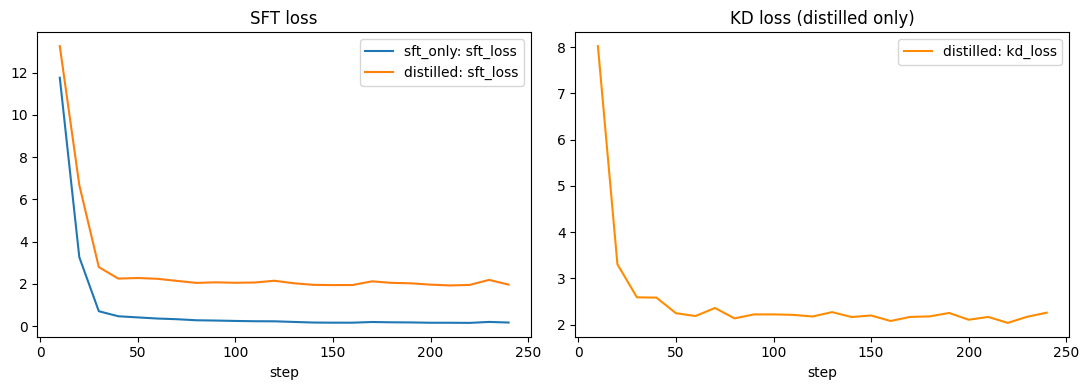

In [8]:
import matplotlib.pyplot as plt

from adbench.data.prepare import read_jsonl
from adbench.training.train import loss_log_path

sft_log = read_jsonl(loss_log_path("sft_only"))
distilled_log = read_jsonl(loss_log_path("distilled"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([r["step"] for r in sft_log], [r["sft_loss"] for r in sft_log], label="sft_only: sft_loss")
axes[0].plot([r["step"] for r in distilled_log], [r["sft_loss"] for r in distilled_log], label="distilled: sft_loss")
axes[0].set_title("SFT loss")
axes[0].set_xlabel("step")
axes[0].legend()

axes[1].plot([r["step"] for r in distilled_log], [r["kd_loss"] for r in distilled_log], label="distilled: kd_loss", color="darkorange")
axes[1].set_title("KD loss (distilled only)")
axes[1].set_xlabel("step")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. EvaluationRuns base / SFT-only / distilled students through the agentic harness at chain lengths 1, 3, 5, plus the general-LM perplexity baseline. No per-task progress output - only a `=== Evaluating <condition> ===` line at the start of each condition and a summary line at the end, so a long quiet gap while this runs is expected, not stuck (as long as the run is still active).

In [9]:
from adbench.evaluation.run_eval import evaluate_condition, write_eval_outputs
from adbench.training.train import CONDITIONS, REPO_ROOT, load_experiment_config

experiment_config = load_experiment_config("configs/experiment.yaml")
models_config = load_experiment_config("configs/models.yaml")
chain_lengths = experiment_config["harness"]["chain_lengths"]

all_rows = []
perplexities = {}
for condition in CONDITIONS:
    print(f"=== Evaluating {condition} ===")
    rows, perplexity = evaluate_condition(condition, experiment_config, models_config, chain_lengths)
    all_rows.extend(rows)
    perplexities[condition] = perplexity
    print(f"{condition}: {len(rows)} tasks run, perplexity={perplexity:.2f}")

output = write_eval_outputs(all_rows, perplexities, REPO_ROOT / "results")
print("wrote results/eval_results.jsonl, eval_results.csv, eval_summary.json")

=== Evaluating base ===
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 3.257 GiB
no_split classes   : ['Qwen3DecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.166 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  12.95 GiB  weights  1.760 GiB  free 11.192 GiB  reserve 11.166 GiB
  cuda:1  budget  13.00 GiB  weights  1.497 GiB  free 11.499 GiB  reserve

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Unsloth 2026.9.5 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
`use_return_dict` is deprecated! Use `return_dict` instead!


base: 121 tasks run, perplexity=18.30
=== Evaluating sft_only ===
==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 3.257 GiB
no_split classes   : ['Qwen3DecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 8.474 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  10.03 GiB  weights  1.572 GiB  free  8.462 GiB  reserve  8.445 GiB
  cuda:1  budget  10.53 GiB  weights  1.685 GiB  free  8.845 GiB  reserve  8.474 GiB   <- output head
note: Bnb4BitHfQuantizer.adjust_max_memory lowered the budget on cud

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

sft_only: 121 tasks run, perplexity=16.30
=== Evaluating distilled ===
==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 3.257 GiB
no_split classes   : ['Qwen3DecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 8.465 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  10.24 GiB  weights  1.760 GiB  free  8.482 GiB  reserve  8.465 GiB
  cuda:1  budget  10.30 GiB  weights  1.497 GiB  free  8.806 GiB  reserve  8.316 GiB   <- output head
note: Bnb4BitHfQuantizer.adjust_max_memory lowered the budget o

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

distilled: 121 tasks run, perplexity=18.04
wrote results/eval_results.jsonl, eval_results.csv, eval_summary.json


### Results`output["summary"]` (one entry per condition x chain length) already has everything below - this just tabulates/plots it.

In [10]:
import pandas as pd

summary_df = pd.DataFrame(output["summary"])
summary_df[["condition", "chain_length", "n_tasks", "full_chain_success_rate",
            "per_step_success_rate", "clean_step_success_rate", "recovery_rate", "perplexity"]]

,condition,chain_length,n_tasks,full_chain_success_rate,per_step_success_rate,clean_step_success_rate,recovery_rate,perplexity
0,base,1,46,0.913043,0.913043,0.739130,0.666667,18.300994
1,base,3,40,0.700000,0.899160,0.672269,0.800000,18.300994
2,base,5,35,0.742857,0.946108,0.880240,1.000000,18.300994
3,distilled,1,46,0.043478,0.043478,0.043478,0.000000,18.039344
4,distilled,3,40,0.000000,0.000000,0.000000,0.000000,18.039344
5,distilled,5,35,0.000000,0.000000,0.000000,0.000000,18.039344
6,sft_only,1,46,0.000000,0.000000,0.000000,0.000000,16.297176
7,sft_only,3,40,0.000000,0.000000,0.000000,0.000000,16.297176
8,sft_only,5,35,0.000000,0.000000,0.000000,0.000000,16.297176


### Success rate vs chain length - the key figure for the research question

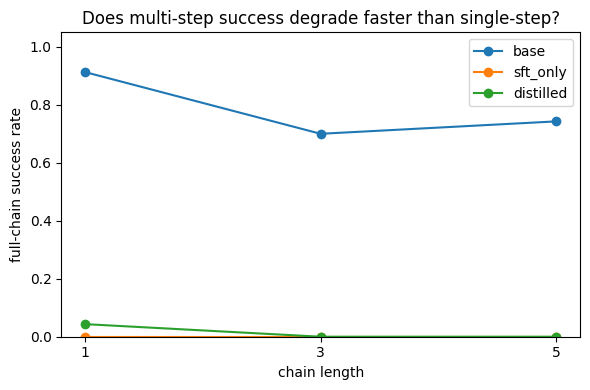

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
for condition in CONDITIONS:
    sub = summary_df[summary_df["condition"] == condition].sort_values("chain_length")
    ax.plot(sub["chain_length"], sub["full_chain_success_rate"], marker="o", label=condition)
ax.set_xlabel("chain length")
ax.set_ylabel("full-chain success rate")
ax.set_xticks(chain_lengths)
ax.set_ylim(0, 1.05)
ax.set_title("Does multi-step success degrade faster than single-step?")
ax.legend()
plt.tight_layout()
plt.show()

### Error breakdown per condition (protocol vs tool-execution)

In [12]:
from adbench.evaluation.metrics import error_category_breakdown

for condition in CONDITIONS:
    condition_rows = [r for r in all_rows if r["condition"] == condition]
    print(condition, error_category_breakdown(condition_rows))

base {'protocol': 25}
sft_only {'protocol': 121}
distilled {'protocol': 119}


## 4. Layer-wise activation analysisCompares teacher (Qwen3-14B) vs the trained student checkpoint's activations on the same probe inputs, per layer, split by attention output vs FFN output, to localize where the representational gap originates - the paper's key mechanistic figure. Loads one model at a time (teacher, then student), caching activations to disk and freeing each before loading the next - the two are never resident together.

In [13]:
from adbench.analysis.layer_analysis import (
    align_layers,
    compare_cached_activations,
    count_layers,
    extract_and_cache_activations,
    load_general_probe_texts,
    load_tool_use_probe_texts,
    write_layer_analysis_results,
)

STUDENT_CONDITION = "distilled"  # the primary comparison; "sft_only" or "base" also work

data_config_path = "configs/data.yaml"
la_config = experiment_config["layer_analysis"]
cache_dir = REPO_ROOT / la_config["cache_dir"]

tool_use_texts = load_tool_use_probe_texts(data_config_path, la_config["n_probe_examples"], la_config["seed"])
general_texts = load_general_probe_texts(experiment_config, la_config["n_probe_examples"])
print(f"{len(tool_use_texts)} tool_use probes, {len(general_texts)} general probes")

50 tool_use probes, 50 general probes


In [14]:
# Teacher and student share the identical tokenizer (verified -
# scripts/verify_tokenizer_compatibility.py), so one tokenizer, loaded once,
# is reused for both extraction passes below.
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(models_config["student"]["hf_id"])

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

### Step 1 - teacher: extract & cache, then free

In [15]:
import gc

import torch

from adbench.training.train import load_teacher

teacher_model = load_teacher(models_config)
n_teacher_layers = count_layers(teacher_model)
print(f"teacher: {n_teacher_layers} layers")

extract_and_cache_activations(
    teacher_model, tokenizer, tool_use_texts, cache_dir / "teacher_tool_use",
    max_length=la_config["probe_max_length"],
)
extract_and_cache_activations(
    teacher_model, tokenizer, general_texts, cache_dir / "teacher_general",
    max_length=la_config["probe_max_length"],
)

del teacher_model
gc.collect()
torch.cuda.empty_cache()

==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/443 [00:00<?, ?it/s]

teacher: 40 layers


### Step 2 - student: extract & cache, then free

In [16]:
from adbench.evaluation.run_eval import load_condition_model

student_model, _student_tokenizer = load_condition_model(STUDENT_CONDITION, experiment_config, models_config)
n_student_layers = count_layers(student_model)
print(f"{STUDENT_CONDITION}: {n_student_layers} layers")

extract_and_cache_activations(
    student_model, tokenizer, tool_use_texts, cache_dir / "student_tool_use",
    max_length=la_config["probe_max_length"],
)
extract_and_cache_activations(
    student_model, tokenizer, general_texts, cache_dir / "student_general",
    max_length=la_config["probe_max_length"],
)

del student_model
gc.collect()
torch.cuda.empty_cache()

==((====))==  Unsloth 2026.9.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 3.257 GiB
no_split classes   : ['Qwen3DecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.057 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  12.88 GiB  weights  1.807 GiB  free 11.077 GiB  reserve 11.057 GiB
  cuda:1  budget  12.85 GiB  weights  1.450 GiB  free 11.396 GiB  reserve 10.862 GiB   <- output head
note: Bnb4BitHfQuantizer.adjust_max_memory lowered the budget on cuda:0 14.315 -> 12.884 GiB, cuda:1 14.274 -> 12.847 GiB (memory the

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

distilled: 36 layers


ValueError: need at least one array to stack

### Step 3 - compare (no models loaded - just the two cache files)

In [ ]:
# student layer i -> teacher layer align_layers[i] (configs/models.yaml: layer_alignment)
layer_alignment = align_layers(n_student_layers, n_teacher_layers)

rows_tool_use = compare_cached_activations(
    cache_dir / "student_tool_use", cache_dir / "teacher_tool_use",
    layer_alignment, metrics=tuple(la_config["divergence_metrics"]), input_set="tool_use",
)
rows_general = compare_cached_activations(
    cache_dir / "student_general", cache_dir / "teacher_general",
    layer_alignment, metrics=tuple(la_config["divergence_metrics"]), input_set="general",
)
layer_rows = rows_tool_use + rows_general

write_layer_analysis_results(layer_rows, REPO_ROOT / la_config["results_path"])
print(f"{len(layer_rows)} rows written to {la_config['results_path']}")

### PlotDivergence vs layer depth, one line per input set (`tool_use` vs `general`) - a separate panel per stream (attention/FFN) and per metric. Where the `tool_use` line diverges from `general` is where the gap looks tool-use-specific, not just generic distillation drift; where both lines move together, it's likely the latter.

In [ ]:
import pandas as pd

df = pd.DataFrame(layer_rows)
streams = ["attention", "ffn"]
metrics = la_config["divergence_metrics"]

fig, axes = plt.subplots(len(metrics), len(streams), figsize=(11, 4 * len(metrics)), squeeze=False)
for row_idx, metric in enumerate(metrics):
    for col_idx, stream in enumerate(streams):
        ax = axes[row_idx][col_idx]
        for input_set, color in [("tool_use", "tab:red"), ("general", "tab:blue")]:
            sub = df[(df["stream"] == stream) & (df["input_set"] == input_set)].sort_values("source_layer")
            ax.plot(sub["source_layer"], sub[metric], marker="o", label=input_set, color=color)
        ax.set_title(f"{stream} - {metric}")
        ax.set_xlabel("student layer index")
        ax.set_ylabel(metric)
        ax.legend()
plt.tight_layout()
plt.show()